<a href="https://colab.research.google.com/github/Golu-yadav-2007/algo-strategies-mini-project-Kartik-Yadav/blob/main/Notebooks/algo_strategies_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

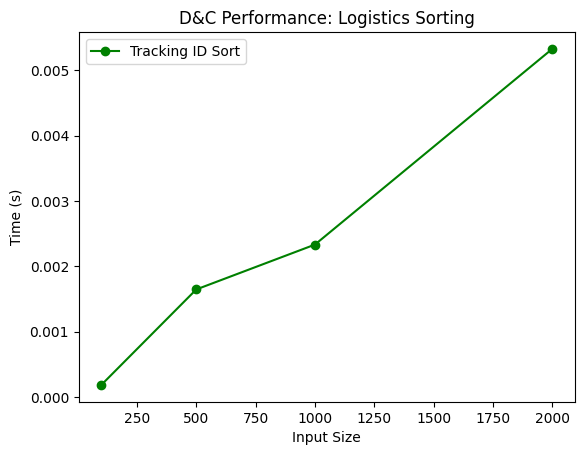

In [3]:
#1 and 2 DIVIDE AND CONQUER
#Complexity: Average case O(n \log n)
import time, random, matplotlib.pyplot as plt

def quicksort_logistics(arr):
    if len(arr) <= 1: return arr
    pivot = arr[len(arr)//2]
    left = [x for x in arr if x < pivot]; mid = [x for x in arr if x == pivot]; right = [x for x in arr if x > pivot]
    return quicksort_logistics(left) + mid + quicksort_logistics(right)

def plot_sorting():
    sizes = [100, 500, 1000, 2000]
    times = []
    for s in sizes:
        data = [random.randint(1000, 9999) for _ in range(s)]
        start = time.time()
        quicksort_logistics(data)
        times.append(time.time() - start)
    plt.plot(sizes, times, marker='o', color='g', label='Tracking ID Sort')
    plt.title("D&C Performance: Logistics Sorting")
    plt.xlabel("Input Size"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_sorting()

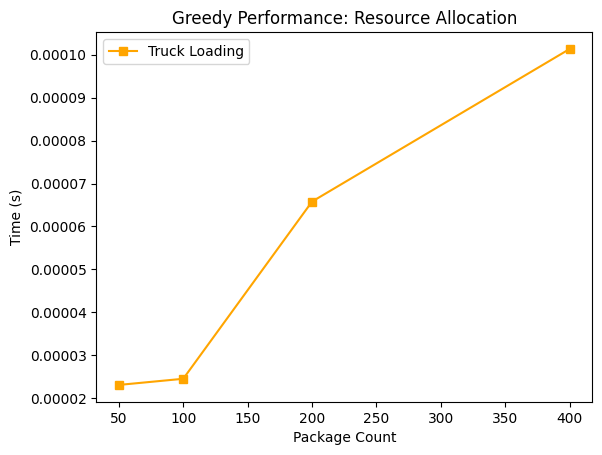

In [4]:
#3. GREEDY STRATEGY
#Time Complexity: O(n \log n) due to initial sorting
def fractional_knapsack_greedy(cap, items):
    items.sort(key=lambda x: x[0]/x[1], reverse=True)
    val = 0.0
    for v, w in items:
        if cap >= w: cap -= w; val += v
        else: val += v * (cap/w); break
    return val

def plot_greedy():
    sizes = [50, 100, 200, 400]
    times = []
    for s in sizes:
        items = [(random.randint(10, 100), random.randint(1, 10)) for _ in range(s)]
        start = time.time(); fractional_knapsack_greedy(100, items); times.append(time.time() - start)
    plt.plot(sizes, times, marker='s', color='orange', label='Truck Loading')
    plt.title("Greedy Performance: Resource Allocation")
    plt.xlabel("Package Count"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_greedy()

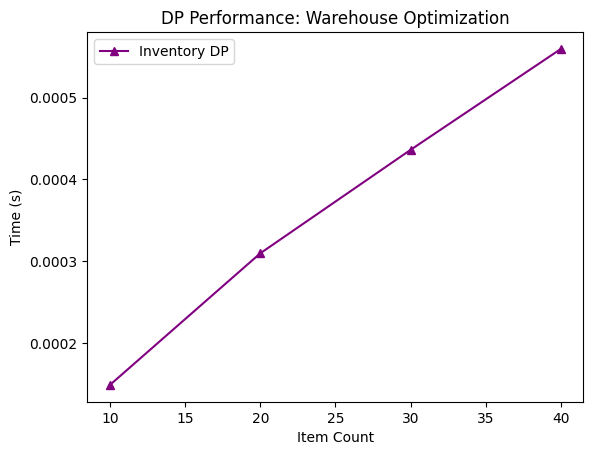

In [5]:
#4 Dynamic Programming
#Complexity: O(n \c. W)
def dp_knapsack(W, wt, val, n):
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(1, W + 1):
            if wt[i-1] <= w: dp[i][w] = max(val[i-1] + dp[i-1][w-wt[i-1]], dp[i-1][w])
            else: dp[i][w] = dp[i-1][w]
    return dp[n][W]

def plot_dp():
    sizes = [10, 20, 30, 40]
    times = []
    for s in sizes:
        wt = [random.randint(1, 10) for _ in range(s)]; v = [random.randint(10, 50) for _ in range(s)]
        start = time.time(); dp_knapsack(50, wt, v, s); times.append(time.time() - start)
    plt.plot(sizes, times, marker='^', color='purple', label='Inventory DP')
    plt.title("DP Performance: Warehouse Optimization")
    plt.xlabel("Item Count"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_dp()

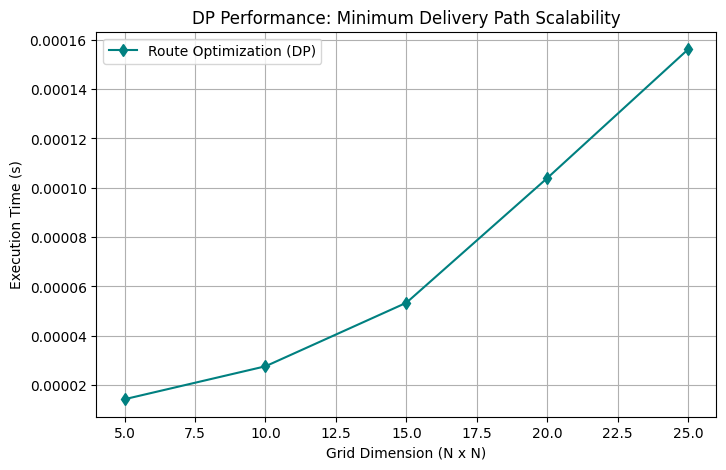

In [8]:
#5. ROUTE OPTIMIZATION
#Complexity: O(M \times N) where M and N are the dimensions of the grid.
def min_delivery_path(grid):
    """Calculates min cost to reach the destination in a grid."""
    m, n = len(grid), len(grid[0])
    # Create a DP table to store results
    dp = [[0 for _ in range(n)] for _ in range(m)]

    dp[0][0] = grid[0][0]

    # Initialize first row and column
    for i in range(1, m): dp[i][0] = dp[i-1][0] + grid[i][0]
    for j in range(1, n): dp[0][j] = dp[0][j-1] + grid[0][j]

    # Fill the rest of the DP table
    for i in range(1, m):
        for j in range(1, n):
            dp[i][j] = grid[i][j] + min(dp[i-1][j], dp[i][j-1])

    return dp[m-1][n-1]
def plot_path_performance():
    sizes = [5, 10, 15, 20, 25]
    times = []

    for s in sizes:
        # Generate a random s x s cost grid
        test_grid = [[random.randint(1, 10) for _ in range(s)] for _ in range(s)]
        start = time.time()
        min_delivery_path(test_grid)
        times.append(time.time() - start)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, times, marker='d', color='teal', label='Route Optimization (DP)')
    plt.title("DP Performance: Minimum Delivery Path Scalability")
    plt.xlabel("Grid Dimension (N x N)")
    plt.ylabel("Execution Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_path_performance()